In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# STEP 1: DATA COLLECTION
# 2024 Nigerian Federal Budget - Sector Allocations (in Billions of Naira)
# Source: BudgIT 2024 Budget Analysis

budget_data = "Security and Defense:3880,Education:2370,Infrastructure:1910,Health:1480,Agriculture:1010,Social Development:662,Power:418,Transportation:110,Communication:29,Solid Minerals:32"

print("Raw data collected successfully.")
print("Length of string:", len(budget_data), "characters")

Raw data collected successfully.
Length of string: 176 characters


In [3]:
# STEP 2: DATA CLEANING

# Split by comma to get individual items
items = budget_data.split(",")
print("Step 1 - Split by comma:")
print(items)

# Split each item by the colon and convert the number to an integer
clean_data = []
for item in items:
    parts = item.split(":")
    sector = parts[0]
    amount = int(parts[1])
    clean_data.append([sector, amount])

print("\nStep 2 - Clean data (list of [sector, amount]):")
print(clean_data)

Step 1 - Split by comma:
['Security and Defense:3880', 'Education:2370', 'Infrastructure:1910', 'Health:1480', 'Agriculture:1010', 'Social Development:662', 'Power:418', 'Transportation:110', 'Communication:29', 'Solid Minerals:32']

Step 2 - Clean data (list of [sector, amount]):
[['Security and Defense', 3880], ['Education', 2370], ['Infrastructure', 1910], ['Health', 1480], ['Agriculture', 1010], ['Social Development', 662], ['Power', 418], ['Transportation', 110], ['Communication', 29], ['Solid Minerals', 32]]


In [4]:
# STEP 3: DATA TRANSFORMATION & MODELING

# Separate into two lists: one for names, one for amounts
sectors = []
amounts = []

for entry in clean_data:
    sectors.append(entry[0])    # The sector name (string)
    amounts.append(entry[1])    # The amount (integer)

print("Sectors:", sectors)
print("\nAmounts (in Billions):", amounts)

Sectors: ['Security and Defense', 'Education', 'Infrastructure', 'Health', 'Agriculture', 'Social Development', 'Power', 'Transportation', 'Communication', 'Solid Minerals']

Amounts (in Billions): [3880, 2370, 1910, 1480, 1010, 662, 418, 110, 29, 32]


In [5]:
# STEP 4: DATA ANALYSIS & EXPLORATION

# --- ANALYSIS 1: Total Allocated Budget ---
total_budget = sum(amounts)
print(f"Total Allocated Budget in this sample: N{total_budget:,} Billion")

# --- ANALYSIS 2: Which sector gets the most? ---
max_amount = max(amounts)
max_index = amounts.index(max_amount)
print(f"\nHighest Allocation: {sectors[max_index]} - N{max_amount:,} Billion")
print(f"Percentage of total: {(max_amount/total_budget)*100:.2f}%")

# --- ANALYSIS 3: Which sector gets the least? ---
min_amount = min(amounts)
min_index = amounts.index(min_amount)
print(f"\nLowest Allocation: {sectors[min_index]} - N{min_amount:,} Billion")
print(f"Percentage of total: {(min_amount/total_budget)*100:.2f}%")

# --- ANALYSIS 4: Percentage of key sectors ---
print("\n--- Percentage of Total Budget by Key Sector ---")
for sector in ["Education", "Health", "Security and Defense", "Agriculture"]:
    if sector in sectors:
        amount = amounts[sectors.index(sector)]
        percentage = (amount / total_budget) * 100
        print(f"{sector}: {percentage:.2f}%")

# --- ANALYSIS 5: The Education vs Security Gap ---
edu_pct = (amounts[sectors.index("Education")] / total_budget) * 100
sec_pct = (amounts[sectors.index("Security and Defense")] / total_budget) * 100
gap = sec_pct - edu_pct
print(f"\nThe Gap: Security is allocated {gap:.2f}% MORE than Education.")

Total Allocated Budget in this sample: N11,901 Billion

Highest Allocation: Security and Defense - N3,880 Billion
Percentage of total: 32.60%

Lowest Allocation: Communication - N29 Billion
Percentage of total: 0.24%

--- Percentage of Total Budget by Key Sector ---
Education: 19.91%
Health: 12.44%
Security and Defense: 32.60%
Agriculture: 8.49%

The Gap: Security is allocated 12.69% MORE than Education.


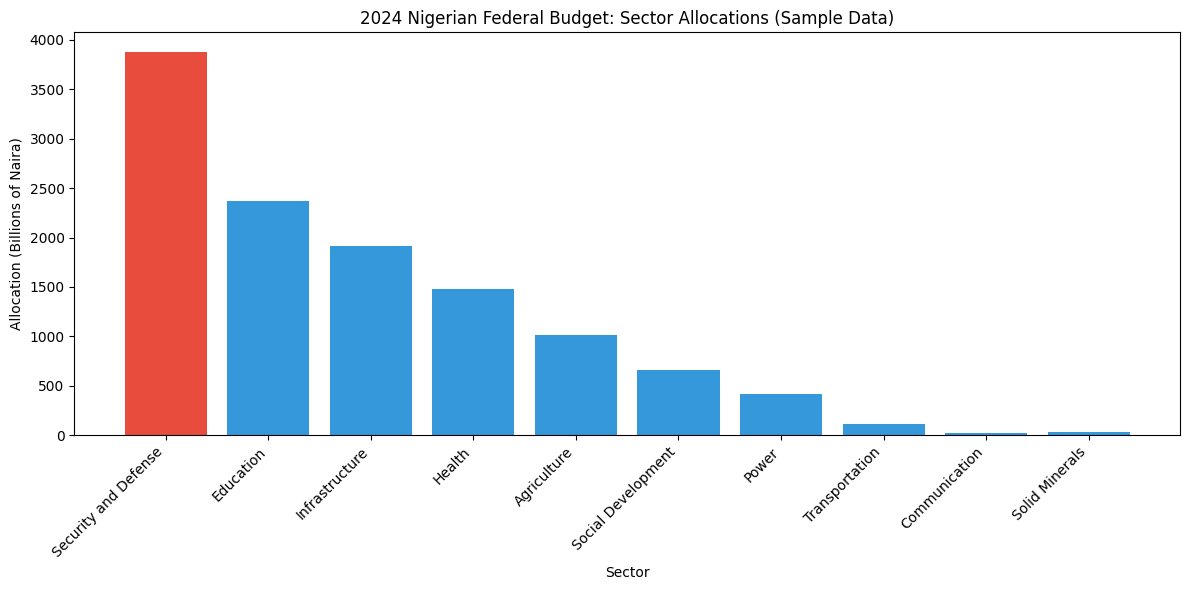

In [6]:
# STEP 5: DATA VISUALIZATION & REPORTING
import matplotlib.pyplot as plt

# Create a bar chart
plt.figure(figsize=(12, 6))

# Highlight Security in red, everything else in blue
colors = ['#e74c3c' if s == "Security and Defense" else '#3498db' for s in sectors]

plt.bar(sectors, amounts, color=colors)
plt.xlabel('Sector')
plt.ylabel('Allocation (Billions of Naira)')
plt.title('2024 Nigerian Federal Budget: Sector Allocations (Sample Data)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2024 Nigerian Federal Budget Analysis
### A Data Analyst's Report

**Methodology:**
Analyzed 2024 Nigerian Federal Budget sector allocations using Python. Data was cleaned, transformed, and visualized to identify government priorities.

**Key Findings:**

| Sector | Allocation (₦ Billions) | % of Total |
| :--- | :--- | :--- |
| Security and Defense | 3,880 | 32.60% |
| Education | 2,370 | 19.91% |
| Health | 1,480 | 12.44% |
| Agriculture | 1,010 | 8.49% |
| Communication | 29 | 0.24% |

**Insights:**

1.  **Security First:** Security and Defense received the largest allocation, taking up **32.60%** of the total budget analyzed—a full **12.69% more** than Education.
2.  **Underfunded Communication:** The Communication sector received only **0.24%** of the budget. This is a concerning gap for a nation pushing for digital transformation.
3.  **Health vs. Security:** Health (12.44%) receives roughly **1/3** of what Security receives. This raises important questions about national priorities.

**Recommendations:**
1.  Consider a gradual rebalancing to increase investment in **Education** and **Health**.
2.  Investigate why **Communication** and **Solid Minerals** receive such minimal funding—these are critical for long-term economic diversification.